# Task 2.2 Mining Cancer Feature Patterns

through sequential pattern mining

### Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('datasets/cancer_data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
print(df.isna().sum()) # check for empty values
duplicate_count = df.duplicated().sum() # check for duplicate rows
print(f"Number of duplicate rows: {duplicate_count}")

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [3]:
# remove empty irrelevant column
df.drop(columns=['Unnamed: 32'], inplace=True)  
# remove ID since it is irrelevant
df = df.drop(columns=['id'])

In [4]:
# Separate features (X) and target (y)
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

## Feature Transformation
### Discretizing Features
converting continuous values to categorical representations (low, medium, high)

In [48]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile', subsample=None)
X_discretized = discretizer.fit_transform(X)
X_discretized_df = pd.DataFrame(X_discretized, columns=X.columns, dtype=int)

bin_labels = {0: '_low', 1: '_medium', 2: '_high'}
for col in X_discretized_df.columns:
    X_discretized_df[col] = X_discretized_df[col].map(bin_labels)

print("\nDiscretized Features Head:")
print(X_discretized_df.head())


Discretized Features Head:
  radius_mean texture_mean perimeter_mean area_mean smoothness_mean  \
0       _high         _low          _high     _high           _high   
1       _high      _medium          _high     _high            _low   
2       _high        _high          _high     _high           _high   
3        _low      _medium           _low      _low           _high   
4       _high         _low          _high     _high         _medium   

  compactness_mean concavity_mean concave points_mean symmetry_mean  \
0            _high          _high               _high         _high   
1          _medium        _medium               _high       _medium   
2            _high          _high               _high         _high   
3            _high          _high               _high         _high   
4            _high          _high               _high       _medium   

  fractal_dimension_mean  ... radius_worst texture_worst perimeter_worst  \
0                  _high  ...        _high

### Defining the Sequence Semantics

mutual information

In [49]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns)
sorted_features_by_mi = mi_scores_series.sort_values(ascending=False)

print("\nTop 10 Features by Mutual Information:")
print(sorted_features_by_mi.head(10))
ranked_feature_names = sorted_features_by_mi.index.tolist()


Top 10 Features by Mutual Information:
perimeter_worst         0.471842
area_worst              0.464313
radius_worst            0.451230
concave points_mean     0.438806
concave points_worst    0.436255
perimeter_mean          0.402361
concavity_mean          0.375447
radius_mean             0.362276
area_mean               0.360023
area_se                 0.340759
dtype: float64


### Create Sequential Representations 
(rank features by their mutual importance)

In [50]:
L = 10 #  max sequence length 

patient_sequences = []

# Iterate through each patient (row)
for i in range(len(df)):
    patient_sequence = []
    patient_discretized_values = X_discretized_df.iloc[i]

    # Create the sequence based on the MI-ranked feature order
    for feature_name in ranked_feature_names[:L]:
        # Get the discretized value (e.g., '_high')
        discretized_value = patient_discretized_values[feature_name]
        # Create the item for the sequence (e.g., 'perimeter_worst_high')
        item = f"{feature_name}{discretized_value}"
        patient_sequence.append(item)
    
    patient_sequences.append(patient_sequence)

# Separate sequences for Malignant and Benign cases
df_sequences = pd.DataFrame({
    'diagnosis': y,
    'sequence': patient_sequences
})

malignant_sequences = df_sequences[df_sequences['diagnosis'] == 1]['sequence'].tolist()
benign_sequences = df_sequences[df_sequences['diagnosis'] == 0]['sequence'].tolist()

print(f"Created {len(malignant_sequences)} malignant sequences.")
print(f"Created {len(benign_sequences)} benign sequences.")
print("\nExample Malignant Sequence:")
print(malignant_sequences[0])
print("\nExample Benign Sequence:")
print(benign_sequences[0])

Created 212 malignant sequences.
Created 357 benign sequences.

Example Malignant Sequence:
['perimeter_worst_high', 'area_worst_high', 'radius_worst_high', 'concave points_mean_high', 'concave points_worst_high', 'perimeter_mean_high', 'concavity_mean_high', 'radius_mean_high', 'area_mean_high', 'area_se_high']

Example Benign Sequence:
['perimeter_worst_medium', 'area_worst_medium', 'radius_worst_medium', 'concave points_mean_medium', 'concave points_worst_medium', 'perimeter_mean_medium', 'concavity_mean_medium', 'radius_mean_medium', 'area_mean_medium', 'area_se_medium']


## Applying GSP (Generalized Sequential Pattern)

trying across different minsup thresholds

support_values = [0.2, 0.3, 0.4, 0.5]

- Higher min support → fewer, stronger patterns (more general)
- Lower min support → more, weaker patterns (more specific, maybe noisy)

In [39]:
!pip install gsppy

from gsppy.gsp import GSP

support_values = [0.1, 0.2, 0.3, 0.4, 0.5]

summary_results = []

for support in support_values:
    print(f"\n=== Running GSP with min_support={support} ===")

    # Run GSP for malignant
    gsp_malignant = GSP(malignant_sequences).search(support)
    num_malignant_patterns = len(gsp_malignant)

    # Run GSP for benign
    gsp_benign = GSP(benign_sequences).search(support)
    num_benign_patterns = len(gsp_benign)

    # Print summary for each
    print(f"Malignant: {num_malignant_patterns} patterns found")
    print(f"Benign: {num_benign_patterns} patterns found")

    # Append to results
    summary_results.append({
        'min_support': support,
        'malignant_patterns': num_malignant_patterns,
        'benign_patterns': num_benign_patterns
    })

# Convert results to DataFrame
summary_df = pd.DataFrame(summary_results)
print("\n=== Summary of Pattern Counts ===")
print(summary_df)


=== Running GSP with min_support=0.1 ===
Malignant: 9 patterns found
Benign: 9 patterns found

=== Running GSP with min_support=0.2 ===
Malignant: 9 patterns found
Benign: 9 patterns found

=== Running GSP with min_support=0.3 ===
Malignant: 9 patterns found
Benign: 4 patterns found

=== Running GSP with min_support=0.4 ===
Malignant: 9 patterns found
Benign: 3 patterns found

=== Running GSP with min_support=0.5 ===
Malignant: 9 patterns found
Benign: 2 patterns found

=== Summary of Pattern Counts ===
   min_support  malignant_patterns  benign_patterns
0          0.1                   9                9
1          0.2                   9                9
2          0.3                   9                4
3          0.4                   9                3
4          0.5                   9                2


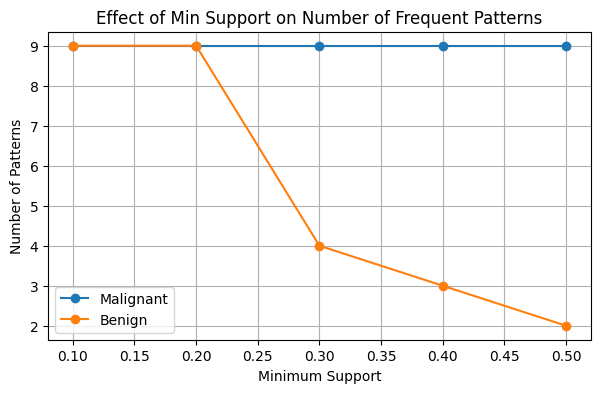

In [40]:
# Plot results
plt.figure(figsize=(7,4))
plt.plot(summary_df['min_support'], summary_df['malignant_patterns'], marker='o', label='Malignant')
plt.plot(summary_df['min_support'], summary_df['benign_patterns'], marker='o', label='Benign')

plt.title('Effect of Min Support on Number of Frequent Patterns')
plt.xlabel('Minimum Support')
plt.ylabel('Number of Patterns')
plt.legend()
plt.grid(True)
plt.show()

Based on the plot above, the number of frequent patterns in malignant sequences remains constant across all support thresholds, indicating highly consistent sequence structures.

In contrast, benign sequences show a sharp decrease in frequent patterns beyond a support threshold of 0.2, suggesting higher variability.
Therefore, a minimum support value of 0.4 was selected for subsequent analyses, as it balances pattern richness with stability and provides clear differentiation between malignant and benign sequence behavior.

In [63]:
def is_subsequence(sub, main):
    """
    Checks if sequence 'sub' is a subsequence of 'main'.
    A is a subsequence of B if all itemsets of A appear in B in the same order.
    
    Example:
        sub = [('a',), ('c',)]
        main = [('a', 'b'), ('d',), ('c', 'e')]
        is_subsequence(sub, main) -> True
    """
    if not sub:
        return True
    if not main:
        return False
    
    # Use two pointers, one for 'sub' (i) and one for 'main' (j)
    i, j = 0, 0
    while i < len(sub) and j < len(main):
        # Check if the current itemset in 'sub' is a subset of the one in 'main'
        if set(sub[i]).issubset(set(main[j])):
            i += 1 
        j += 1  
   
    return i == len(sub)

In [62]:
def find_maximal_patterns(all_patterns_with_support):
    maximal_patterns = []
    
    for pattern_A, support_A in all_patterns_with_support:
        is_maximal = True
        # Check against all other patterns
        for pattern_B, _ in all_patterns_with_support:
            # Skip if comparing to itself
            if pattern_A == pattern_B:
                continue
            
            # If pattern_A is a subsequence of another pattern_B, it is not maximal.
            if is_subsequence(pattern_A, pattern_B):
                is_maximal = False
                break 
        
        if is_maximal:
            maximal_patterns.append((pattern_A, support_A))
            
    return maximal_patterns

In [61]:
min_support = 0.3 

# === Malignant Cases ===
print("--- Analysis for Malignant Sequences ---")

gsp_malignant_results = GSP(malignant_sequences).search(min_support)
malignant_flat = [(pattern, support) for group in gsp_malignant_results for pattern, support in group.items()]
maximal_malignant = find_maximal_patterns(malignant_flat)
malignant_sorted = sorted(maximal_malignant, key=lambda x: x[1], reverse=True)

print(f"\nTop MAXIMAL Frequent Patterns for Malignant Sequences (min_support={min_support}):\n")
print(f"{'Rank':<5}{'Pattern Sequence':<90}{'Support Count':<15}")
print("-" * 110)
for rank, (pattern, support) in enumerate(malignant_sorted, 1):
    print(f"{rank:<5}{str(pattern):<90}{support:<15}")

# === Benign Cases ===
print("\n--- Analysis for Benign Sequences ---")

gsp_benign_results = GSP(benign_sequences).search(min_support)
benign_flat = [(pattern, support) for group in gsp_benign_results for pattern, support in group.items()]
maximal_benign = find_maximal_patterns(benign_flat)
benign_sorted = sorted(maximal_benign, key=lambda x: x[1], reverse=True)

print(f"\nTop MAXIMAL Frequent Patterns for Benign Sequences (min_support={min_support}):\n")
print(f"{'Rank':<5}{'Pattern Sequence':<90}{'Support Count':<15}")
print("-" * 110)
for rank, (pattern, support) in enumerate(benign_sorted, 1):
    print(f"{rank:<5}{str(pattern):<90}{support:<15}")

--- Analysis for Malignant Sequences ---

Top MAXIMAL Frequent Patterns for Malignant Sequences (min_support=0.3):

Rank Pattern Sequence                                                                          Support Count  
--------------------------------------------------------------------------------------------------------------
1    ('perimeter_worst_high', 'area_worst_high', 'radius_worst_high', 'concave points_mean_high', 'concave points_worst_high', 'perimeter_mean_high', 'concavity_mean_high', 'radius_mean_high', 'area_mean_high')126            
2    ('area_worst_high', 'radius_worst_high', 'concave points_mean_high', 'concave points_worst_high', 'perimeter_mean_high', 'concavity_mean_high', 'radius_mean_high', 'area_mean_high', 'area_se_high')116            

--- Analysis for Benign Sequences ---

Top MAXIMAL Frequent Patterns for Benign Sequences (min_support=0.3):

Rank Pattern Sequence                                                                          Support Coun

### Sensitivity Check across different binning methods during discretization

#### Uniform

In [81]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform', subsample=None) # changed the strategy
X_discretized = discretizer.fit_transform(X)
X_discretized_df = pd.DataFrame(X_discretized, columns=X.columns, dtype=int)

bin_labels = {0: '_low', 1: '_medium', 2: '_high'}
for col in X_discretized_df.columns:
    X_discretized_df[col] = X_discretized_df[col].map(bin_labels)

print("Discretized Features Head:")
print(X_discretized_df.head())


L = 10 #  max sequence length 

patient_sequences = []

for i in range(len(df)):
    patient_sequence = []
    patient_discretized_values = X_discretized_df.iloc[i]

    # Create the sequence based on the MI-ranked feature order
    for feature_name in ranked_feature_names[:L]:
        # Get the discretized value (e.g., '_high')
        discretized_value = patient_discretized_values[feature_name]
        # Create the item for the sequence (e.g., 'perimeter_worst_high')
        item = f"{feature_name}{discretized_value}"
        patient_sequence.append(item)
    
    patient_sequences.append(patient_sequence)

# Separate sequences for Malignant and Benign cases
df_sequences = pd.DataFrame({
    'diagnosis': y,
    'sequence': patient_sequences
})

malignant_sequences = df_sequences[df_sequences['diagnosis'] == 1]['sequence'].tolist()
benign_sequences = df_sequences[df_sequences['diagnosis'] == 0]['sequence'].tolist()

print(f"Created {len(malignant_sequences)} malignant sequences.")
print(f"Created {len(benign_sequences)} benign sequences.")
print("\nExample Malignant Sequence:")
print(malignant_sequences[0])
print("\nExample Benign Sequence:")
print(benign_sequences[0])

min_support = 0.3 

# === Malignant Cases ===
print("--- Analysis for Malignant Sequences ---")

gsp_malignant_results = GSP(malignant_sequences).search(min_support)
malignant_flat = [(pattern, support) for group in gsp_malignant_results for pattern, support in group.items()]
maximal_malignant = find_maximal_patterns(malignant_flat)
malignant_sorted = sorted(maximal_malignant, key=lambda x: x[1], reverse=True)

print(f"\nTop MAXIMAL Frequent Patterns for Malignant Sequences (min_support={min_support}):\n")
print(f"{'Rank':<5}{'Pattern Sequence':<90}{'Support Count':<15}")
print("-" * 110)
for rank, (pattern, support) in enumerate(malignant_sorted, 1):
    print(f"{rank:<5}{str(pattern):<90}{support:<15}")

# === Benign Cases ===
print("\n--- Analysis for Benign Sequences ---")

gsp_benign_results = GSP(benign_sequences).search(min_support)
benign_flat = [(pattern, support) for group in gsp_benign_results for pattern, support in group.items()]
maximal_benign = find_maximal_patterns(benign_flat)
benign_sorted = sorted(maximal_benign, key=lambda x: x[1], reverse=True)

print(f"\nTop MAXIMAL Frequent Patterns for Benign Sequences (min_support={min_support}):\n")
print(f"{'Rank':<5}{'Pattern Sequence':<90}{'Support Count':<15}")
print("-" * 110)
for rank, (pattern, support) in enumerate(benign_sorted, 1):
    print(f"{rank:<5}{str(pattern):<90}{support:<15}")

Discretized Features Head:
  radius_mean texture_mean perimeter_mean area_mean smoothness_mean  \
0     _medium         _low        _medium   _medium         _medium   
1     _medium         _low        _medium   _medium            _low   
2     _medium      _medium        _medium   _medium         _medium   
3        _low      _medium           _low      _low           _high   
4     _medium         _low        _medium   _medium         _medium   

  compactness_mean concavity_mean concave points_mean symmetry_mean  \
0            _high          _high               _high         _high   
1             _low           _low             _medium       _medium   
2          _medium        _medium             _medium       _medium   
3            _high        _medium             _medium         _high   
4          _medium        _medium             _medium       _medium   

  fractal_dimension_mean  ... radius_worst texture_worst perimeter_worst  \
0                _medium  ...      _medium 

#### K-Means

In [80]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans', subsample=None) # changed the strategy
X_discretized = discretizer.fit_transform(X)
X_discretized_df = pd.DataFrame(X_discretized, columns=X.columns, dtype=int)

bin_labels = {0: '_low', 1: '_medium', 2: '_high'}
for col in X_discretized_df.columns:
    X_discretized_df[col] = X_discretized_df[col].map(bin_labels)

print("Discretized Features Head:")
print(X_discretized_df.head())

L = 10 #  max sequence length 

patient_sequences = []

for i in range(len(df)):
    patient_sequence = []
    patient_discretized_values = X_discretized_df.iloc[i]

    # Create the sequence based on the MI-ranked feature order
    for feature_name in ranked_feature_names[:L]:
        # Get the discretized value (e.g., '_high')
        discretized_value = patient_discretized_values[feature_name]
        # Create the item for the sequence (e.g., 'perimeter_worst_high')
        item = f"{feature_name}{discretized_value}"
        patient_sequence.append(item)
    
    patient_sequences.append(patient_sequence)

# Separate sequences for Malignant and Benign cases
df_sequences = pd.DataFrame({
    'diagnosis': y,
    'sequence': patient_sequences
})

malignant_sequences = df_sequences[df_sequences['diagnosis'] == 1]['sequence'].tolist()
benign_sequences = df_sequences[df_sequences['diagnosis'] == 0]['sequence'].tolist()

print(f"Created {len(malignant_sequences)} malignant sequences.")
print(f"Created {len(benign_sequences)} benign sequences.")
print("\nExample Malignant Sequence:")
print(malignant_sequences[0])
print("\nExample Benign Sequence:")
print(benign_sequences[0])

min_support = 0.3 

# === Malignant Cases ===
print("--- Analysis for Malignant Sequences ---")

gsp_malignant_results = GSP(malignant_sequences).search(min_support)
malignant_flat = [(pattern, support) for group in gsp_malignant_results for pattern, support in group.items()]
maximal_malignant = find_maximal_patterns(malignant_flat)
malignant_sorted = sorted(maximal_malignant, key=lambda x: x[1], reverse=True)

print(f"\nTop MAXIMAL Frequent Patterns for Malignant Sequences (min_support={min_support}):\n")
print(f"{'Rank':<5}{'Pattern Sequence':<90}{'Support Count':<15}")
print("-" * 110)
for rank, (pattern, support) in enumerate(malignant_sorted, 1):
    print(f"{rank:<5}{str(pattern):<90}{support:<15}")

# === Benign Cases ===
print("\n--- Analysis for Benign Sequences ---")

gsp_benign_results = GSP(benign_sequences).search(min_support)
benign_flat = [(pattern, support) for group in gsp_benign_results for pattern, support in group.items()]
maximal_benign = find_maximal_patterns(benign_flat)
benign_sorted = sorted(maximal_benign, key=lambda x: x[1], reverse=True)

print(f"\nTop MAXIMAL Frequent Patterns for Benign Sequences (min_support={min_support}):\n")
print(f"{'Rank':<5}{'Pattern Sequence':<90}{'Support Count':<15}")
print("-" * 110)
for rank, (pattern, support) in enumerate(benign_sorted, 1):
    print(f"{rank:<5}{str(pattern):<90}{support:<15}")

Discretized Features Head:
  radius_mean texture_mean perimeter_mean area_mean smoothness_mean  \
0       _high         _low          _high   _medium           _high   
1       _high      _medium          _high   _medium            _low   
2       _high      _medium          _high   _medium           _high   
3        _low      _medium           _low      _low           _high   
4       _high         _low          _high   _medium         _medium   

  compactness_mean concavity_mean concave points_mean symmetry_mean  \
0            _high          _high               _high         _high   
1             _low        _medium             _medium       _medium   
2          _medium        _medium               _high       _medium   
3            _high          _high             _medium         _high   
4          _medium        _medium             _medium       _medium   

  fractal_dimension_mean  ... radius_worst texture_worst perimeter_worst  \
0                  _high  ...        _high 